In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos del enunciado
YearsExperience = np.array([
 1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5
])

Salary = np.array([
 39343.0, 46205.0, 37731.0, 43525.0, 39891.0,
 56642.0, 60150.0, 54445.0, 64445.0, 57189.0,
 63218.0, 55794.0, 56957.0, 57081.0, 61111.0,
 67938.0, 66029.0, 83088.0, 81363.0, 93940.0,
 91738.0, 98273.0, 101302.0, 113812.0, 109431.0,
 105582.0, 116969.0, 112635.0, 122391.0, 121872.0
])

def estimate_coef(x, y):
    # Número de observaciones
    n = np.size(x)

    # Promedios de x e y
    m_x = np.mean(x)
    m_y = np.mean(y)

    # Cálculo de los componentes de la fórmula de forma vectorizada
    # Sumatoria de (x_i - mean(x)) * (y_i - mean(y))
    SS_xy = np.sum((x - m_x) * (y - m_y))
    # Sumatoria de (x_i - mean(x))^2
    SS_xx = np.sum((x - m_x) ** 2)

    # Cálculo de los coeficientes b_1 y b_0
    beta_1 = SS_xy / SS_xx
    beta_0 = m_y - beta_1 * m_x

    return (beta_0, beta_1)

# Calcular e imprimir coeficientes estimados
beta_estimado = estimate_coef(YearsExperience, Salary)
print(f"Coeficientes estimados:\nb_0 = {beta_estimado[0]:.4f} \nb_1 = {beta_estimado[1]:.4f}")

Coeficientes estimados:
b_0 = 25792.2002 
b_1 = 9449.9623


Visualizacion del modelo ajustado

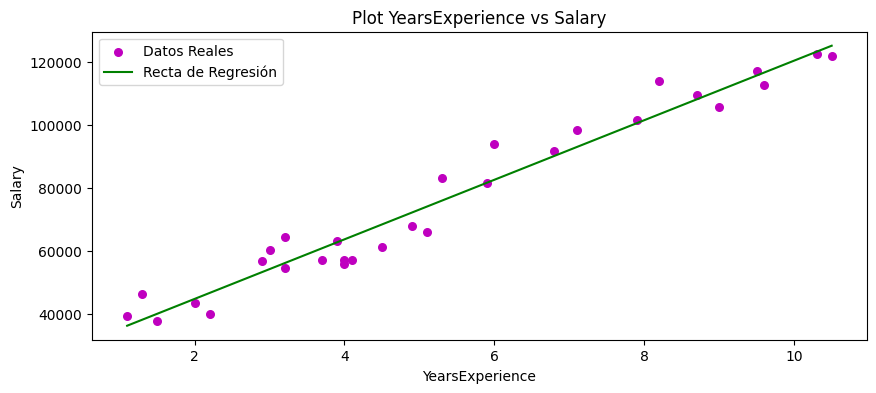

In [2]:
def plot_regression_line(x, y, yhat):
    plt.figure(figsize=(10,4))
    # Puntos reales
    plt.scatter(x, y, color = "m", marker = "o", s = 30, label="Datos Reales")
    # Línea de regresión
    plt.plot(x, yhat, color = "g", label="Recta de Regresión")

    plt.xlabel('YearsExperience')
    plt.ylabel('Salary')
    plt.title("Plot YearsExperience vs Salary")
    plt.legend()
    plt.show()

# Mostrar resultados del ajuste lineal
prediccion = beta_estimado[0] + beta_estimado[1] * YearsExperience
plot_regression_line(YearsExperience, Salary, prediccion)

Evaluacion cuantitativa del modelo

In [3]:
def mae(y, yhat) -> float:
    # Promedio de las diferencias absolutas
    return np.mean(np.abs(y - yhat))

def rmse(y, yhat) -> float:
    # Raíz del promedio de los errores al cuadrado
    return np.sqrt(np.mean((y - yhat) ** 2))

def mape(y, yhat) -> float:
    # Error porcentual absoluto medio
    return np.mean(np.abs((y - yhat) / y))

def smape(y, yhat) -> float:
    # Error porcentual absoluto medio simétrico
    numerador = np.abs(yhat - y)
    denominador = (np.abs(y) + np.abs(yhat)) / 2
    return np.mean(numerador / denominador)

def rsquared(y, yhat) -> float:
    m_y = np.mean(y)
    # Suma de residuos al cuadrado (RSS)
    ss_res = np.sum((y - yhat) ** 2)
    # Suma total de cuadrados (TSS)
    ss_tot = np.sum((y - m_y) ** 2)

    # R^2 = 1 - (SS_res / SS_tot)
    return 1 - (ss_res / ss_tot)

# Calcular resultados
calcular_mae = round(mae(Salary, prediccion), 4)
calcular_rmse = round(rmse(Salary, prediccion), 4)
calcular_mape = round(mape(Salary, prediccion), 4)
calcular_smape = round(smape(Salary, prediccion), 4)
calcular_rsquared = round(rsquared(Salary, prediccion), 4)

# Imprimir resultados numéricos
print(f"mae:   {calcular_mae}")
print(f"rmse:  {calcular_rmse}")
print(f"mape:  {calcular_mape}")
print(f"smape: {calcular_smape}")
print(f"r^2:   {calcular_rsquared}")

mae:   4644.2013
rmse:  5592.0436
mape:  0.0705
smape: 0.0704
r^2:   0.957


Análisis de resultados y conclusiones

Capacidad explicativa ($R^2$): El coeficiente de determinación obtenido es de 0.957. Esto indica que el modelo de regresión lineal simple logra explicar aproximadamente el 95.7% de la variabilidad total de los salarios en función de los años de experiencia. Al estar muy cerca de 1, demuestra una capacidad predictiva y de ajuste extremadamente alta.Magnitud de los errores (MAE, RMSE, MAPE, sMAPE): El error porcentual (MAPE/sMAPE) se sitúa en torno al 7% - 8%, lo cual es un margen de error muy bajo para contextos económicos y laborales. El MAE y el RMSE son consistentes entre sí y pequeños si los comparamos con el rango de la variable respuesta (los salarios van desde $\$37.000$ hasta más de $\$122.000$).Comportamiento del modelo y alternativas: Al observar la gráfica generada en el punto 2, los puntos reales se distribuyen de manera uniforme y lineal a lo largo de la recta de regresión ajustada. No se aprecian curvaturas pronunciadas ni un comportamiento de heterocedasticidad severo (la dispersión del error se mantiene relativamente constante).Dictamen final: El modelo de regresión lineal simple es completamente adecuado y apropiado para este conjunto de datos. Ofrece un equilibrio perfecto entre simplicidad interpretativa y precisión matemática. No se requiere migrar a modelos polinomiales o complejos debido a que el residuo no explicado es marginal (menor al 5%).